In [1]:
import os
import json
import hashlib
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from sklearn.cluster import AgglomerativeClustering
from anytree import Node, RenderTree

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_json("D:/git/Taxonomy_Buidling_Textual_Corpora/data/icecat_data_train.json")

In [3]:
df_small = df.head(1000).copy()
df_small.shape

(1000, 45)

In [4]:
df_small

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,...,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names
1072689,ASUS,,https://images.icecat.biz/img/brand/thumb/161_...,ASUS,https://images.icecat.biz/img/brand/thumb/161_...,K31CD-IT049T,[],153,EN,PCs/Workstations,...,None,None,NaN,None,None,None,"[{'VirtualCategoryID': 195, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...
906402,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,686915-A41,[],2509,EN,Notebook Spare Parts,...,None,None,NaN,None,None,None,None,NaN,2833>150>8355>2509,Computers & Electronics>Computers>Notebook Par...
411281,C2G,,https://images.icecat.biz/img/brand/thumb/2834...,C2G,https://images.icecat.biz/img/brand/thumb/2834...,37745,[],953,EN,Fibre Optic Cables,...,None,None,NaN,None,None,None,None,NaN,2833>830>953,Computers & Electronics>Computer Cables>Fibre ...
425903,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,FA889AA#AC3,[],8194,EN,Handheld Mobile Computer Spare Parts,...,None,None,NaN,None,None,None,None,NaN,2833>150>8194,Computers & Electronics>Computers>Handheld Mob...
1047582,Lenovo,,https://images.icecat.biz/img/brand/thumb/728_...,Lenovo,https://images.icecat.biz/img/brand/thumb/728_...,109559U,[],153,EN,PCs/Workstations,...,None,None,NaN,None,None,None,"[{'VirtualCategoryID': 194, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392099,C2G,,https://images.icecat.biz/img/brand/thumb/2834...,C2G,https://images.icecat.biz/img/brand/thumb/2834...,37079,[],1056,EN,Flat Panel Wall Mounts,...,None,None,NaN,None,None,None,None,NaN,2833>220>1056,Computers & Electronics>TVs & Monitors>Flat Pa...
1008636,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,SIC1297184LCD0,[],2509,EN,Notebook Spare Parts,...,None,None,NaN,None,None,None,None,NaN,2833>150>8355>2509,Computers & Electronics>Computers>Notebook Par...
581225,Middle Atlantic Products,,https://images.icecat.biz/img/brand/thumb/2702...,Middle Atlantic Products,https://images.icecat.biz/img/brand/thumb/2702...,WUSS14,None,1532,EN,Rack Accessories,...,None,None,1967411.0,EN,2019-04-17 12:12:17,[Holds components too wide for standard racksh...,None,NaN,2833>106>236>1532,Computers & Electronics>Computer Components>Ch...
301585,Philips,,https://images.icecat.biz/img/brand/thumb/25_b...,Philips,https://images.icecat.biz/img/brand/thumb/25_b...,55PUS6272/12,None,1584,EN,TVs,...,None,None,417921.0,EN,2018-02-01 09:50:04,"[139 cm (55""), 4K Ultra-HD LED TV, Quad Core, ...",None,NaN,2833>220>1584,Computers & Electronics>TVs & Monitors>TVs


STEP 1 — Extract A, B, C Taxonomy Levels

Use a robust splitter that handles:
2-level
3-level
4+ level paths
(some Icecat paths have 4 levels!)

In [5]:
def split_taxonomy(path):
    """
    Handle 2, 3, 4+ levels in pathlist_names.
    A = root
    B = second level
    C = everything below B (joined back with '>').
    """
    if pd.isna(path):
        return pd.Series([None, None, None])

    parts = [p.strip() for p in str(path).split(">")]

    # A > B
    if len(parts) == 2:
        return pd.Series([parts[0], parts[1], None])

    # A > B > C
    if len(parts) == 3:
        return pd.Series([parts[0], parts[1], parts[2]])

    # A > B > C > D --> treat C as "C > D"
    return pd.Series([parts[0], parts[1], ">".join(parts[2:])])


In [6]:
df_small[["A", "B", "C"]] = df_small["pathlist_names"].apply(split_taxonomy)
df_small[["pathlist_names", "A", "B", "C"]].head(10)

,pathlist_names,A,B,C
1072689,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,Computers,PCs/Workstations
906402,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,Computers,Notebook Parts & Accessories>Notebook Spare Parts
411281,Computers & Electronics>Computer Cables>Fibre ...,Computers & Electronics,Computer Cables,Fibre Optic Cables
425903,Computers & Electronics>Computers>Handheld Mob...,Computers & Electronics,Computers,Handheld Mobile Computer Spare Parts
1047582,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,Computers,PCs/Workstations
904910,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,Computers,Notebook Parts & Accessories>Notebook Spare Parts
157385,Computers & Electronics>Software>Software Lice...,Computers & Electronics,Software,Software Licenses/Upgrades
934548,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,Computers,Notebook Parts & Accessories>Notebook Spare Parts
876762,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,Computers,Notebook Parts & Accessories>Notebook Spare Parts
397028,Computers & Electronics>Telecom & Navigation>M...,Computers & Electronics,Telecom & Navigation,Mobile Phone Spare Parts


In [7]:
# df_small = first 1000 rows (for now)
# and you already ran:
df_small[["A", "B", "C"]] = df_small["pathlist_names"].apply(split_taxonomy)


In [8]:
#Global counts: how many A, B, C?
print("Total A-level categories:", df_small["A"].nunique())
print("Total B-level categories:", df_small["B"].nunique())
print("Total C-level categories:", df_small["C"].nunique())


Total A-level categories: 1
Total B-level categories: 16
Total C-level categories: 143


In [9]:
#For each A: how many B and C?
# B per A
A_B_counts = (
    df_small.groupby("A")["B"]
    .nunique()
    .reset_index(name="num_B_under_A")
)

# C per A
A_C_counts = (
    df_small.groupby("A")["C"]
    .nunique()
    .reset_index(name="num_C_under_A")
)

A_summary = A_B_counts.merge(A_C_counts, on="A")
A_summary


,A,num_B_under_A,num_C_under_A
0,Computers & Electronics,16,143


In [10]:
print("=== A-level summary (how many B and C under each A) ===")
for _, row in A_summary.iterrows():
    print(f"A: {row['A']}")
    print(f"  B-level subcategories: {row['num_B_under_A']}")
    print(f"  C-level subcategories: {row['num_C_under_A']}")
    print()


=== A-level summary (how many B and C under each A) ===
A: Computers & Electronics
  B-level subcategories: 16
  C-level subcategories: 143



In [11]:
# For each B: how many C and how many products?
# C per B (within each A)
B_C_counts = (
    df_small.groupby(["A", "B"])["C"]
    .nunique()
    .reset_index(name="num_C_under_B")
)

# products per B
B_prod_counts = (
    df_small.groupby(["A", "B"])["ProductName"]
    .count()
    .reset_index(name="num_products_under_B")
)

B_summary = B_C_counts.merge(B_prod_counts, on=["A", "B"])
B_summary


,A,B,num_C_under_B,num_products_under_B
0,Computers & Electronics,Batteries & Power Supplies,7,27
1,Computers & Electronics,Computer Cables,11,42
2,Computers & Electronics,Computer Components,14,65
3,Computers & Electronics,Computers,15,450
4,Computers & Electronics,Consumer Audio & Video Equipment,13,25
5,Computers & Electronics,Data Input Devices,3,25
6,Computers & Electronics,Data Storage,11,59
7,Computers & Electronics,Networking,7,11
8,Computers & Electronics,Office Electronics,1,1
9,Computers & Electronics,Photo & Video Equipment,8,14


In [12]:
print("=== B-level summary (per A) ===")
for (a, b), sub in B_summary.groupby(["A", "B"]):
    row = sub.iloc[0]
    print(f"A: {a}")
    print(f"  B: {b}")
    print(f"    #C-level subcategories: {row['num_C_under_B']}")
    print(f"    #products (total under this B): {row['num_products_under_B']}")
    print()


=== B-level summary (per A) ===
A: Computers & Electronics
  B: Batteries & Power Supplies
    #C-level subcategories: 7
    #products (total under this B): 27

A: Computers & Electronics
  B: Computer Cables
    #C-level subcategories: 11
    #products (total under this B): 42

A: Computers & Electronics
  B: Computer Components
    #C-level subcategories: 14
    #products (total under this B): 65

A: Computers & Electronics
  B: Computers
    #C-level subcategories: 15
    #products (total under this B): 450

A: Computers & Electronics
  B: Consumer Audio & Video Equipment
    #C-level subcategories: 13
    #products (total under this B): 25

A: Computers & Electronics
  B: Data Input Devices
    #C-level subcategories: 3
    #products (total under this B): 25

A: Computers & Electronics
  B: Data Storage
    #C-level subcategories: 11
    #products (total under this B): 59

A: Computers & Electronics
  B: Networking
    #C-level subcategories: 7
    #products (total under this B): 1

In [14]:
#For each C: how many products?
C_prod_counts = (
    df_small.groupby(["A", "B", "C"])["ProductName"]
    .count()
    .reset_index(name="num_products_under_C")
)

C_prod_counts  # inspect first 20


,A,B,C,num_products_under_C
0,Computers & Electronics,Batteries & Power Supplies,Household Batteries,2
1,Computers & Electronics,Batteries & Power Supplies,Power Adapters & Inverters,14
2,Computers & Electronics,Batteries & Power Supplies,Power Banks,1
3,Computers & Electronics,Batteries & Power Supplies,Power Distribution Units (PDUs),1
4,Computers & Electronics,Batteries & Power Supplies,Power Supply Units,3
...,...,...,...,...
138,Computers & Electronics,Telecom & Navigation,Screen Protectors,8
139,Computers & Electronics,Telecom & Navigation,Smartphones,6
140,Computers & Electronics,Telecom & Navigation,Telephony Equipment>Telephones,2
141,Computers & Electronics,Warranty & Support,IT Support Services,2


In [15]:
print("=== C-level summary (A → B → C → #products) ===")
for (a, b), sub in C_prod_counts.groupby(["A", "B"]):
    print(f"\nA: {a}")
    print(f"  B: {b}")
    for _, row in sub.iterrows():
        print(f"    C: {row['C']}  ({row['num_products_under_C']} products)")


=== C-level summary (A → B → C → #products) ===

A: Computers & Electronics
  B: Batteries & Power Supplies
    C: Household Batteries  (2 products)
    C: Power Adapters & Inverters  (14 products)
    C: Power Banks  (1 products)
    C: Power Distribution Units (PDUs)  (1 products)
    C: Power Supply Units  (3 products)
    C: UPS Batteries  (1 products)
    C: Uninterruptible Power Supplies (UPSs)  (5 products)

A: Computers & Electronics
  B: Computer Cables
    C: Cable Interface/Gender Adapters  (4 products)
    C: Cable Protectors  (1 products)
    C: DisplayPort Cables  (1 products)
    C: Fibre Optic Cables  (7 products)
    C: HDMI Cables  (2 products)
    C: Networking Cables  (18 products)
    C: Power Cables  (3 products)
    C: SCSI Cables  (1 products)
    C: USB Cables  (3 products)
    C: Video Cable Adapters  (1 products)
    C: Wire Connectors  (1 products)

A: Computers & Electronics
  B: Computer Components
    C: Chassis Components>Computer Case Parts  (1 products

In [16]:
def print_full_hierarchy(df):
    # Loop over A-level categories
    for a in df["A"].dropna().unique():
        print(f"\nA: {a}")
        print("=" * 80)

        df_a = df[df["A"] == a]

        # Loop over B-level categories within this A
        for b in df_a["B"].dropna().unique():
            print(f"  B: {b}")

            df_b = df_a[df_a["B"] == b]

            # Loop over C-level categories within this B
            for c in df_b["C"].dropna().unique():
                df_c = df_b[df_b["C"] == c]

                print(f"    C: {c}  ({len(df_c)} products)")

                # Print product names under this C
                for pname in df_c["ProductName"].dropna().tolist():
                    print(f"        • {pname}")

            print()  # space after each B section

# Run it on the sample
print_full_hierarchy(df_small)



A: Computers & Electronics
  B: Computers
    C: PCs/Workstations  (38 products)
        • K31CD-IT049T
        • C30
        • UN42-M031M
        • P310
        • 875-1303ng
        • 400 G6
        • M910q
        • 3 VR7RD-037US
        • 400 G4 + EliteDisplay E223
        • ProDesk 600 G3 Desktop Mini PC
        • G11CD-FR139T
        • S2660G
        • h8-1500et
        • Compaq Presario SG3320IL Desktop PC
        • TC-710
        • XC605
        • DM500T4Z
        • M32CD-IT051T
        • A 8RC-290FR
        • Z640
        • Compaq 6200 Pro Microtower PC (ENERGY STAR)
        • Z440
        • P500
        • 550-131ns
        • 5680
        • P420 E85+
        • M83
        • 595-p0059nl
        • K20CD-KR002D
        • 690-0043ns
        • Aegis Ti3 VR7RD
        • S510 + 19.5" LED ThinkVision E2054
        • 800 G4 + LaserJet Pro M15w
        • 800 G4
        • M73
        • Y700-34ISH
        • M770
        • 690-0999nf
    C: Notebook Parts & Accessories>Notebook Spare Parts

In [17]:
# summarize how many C-categories have 1 product, 2–5, 6–10, etc.
## We already have this:
# C_prod_counts = df_small.groupby(["A", "B", "C"])["ProductName"] \
#                      .count().reset_index(name="num_products_under_C")

# Just keep the counts column
counts = C_prod_counts["num_products_under_C"]

print("Total C-level categories:", len(counts))
print()

# 1. How many C's have exactly 1 product?
c1 = (counts == 1).sum()

# 2. How many have 2–5 products?
c2_5 = ((counts >= 2) & (counts <= 5)).sum()

# 3. How many have 6–10 products?
c6_10 = ((counts >= 6) & (counts <= 10)).sum()

# 4. How many have >10 products?
c10p = (counts > 10).sum()

print("C with exactly 1 product:", c1)
print("C with 2–5 products:", c2_5)
print("C with 6–10 products:", c6_10)
print("C with >10 products:", c10p)


Total C-level categories: 143

C with exactly 1 product: 55
C with 2–5 products: 60
C with 6–10 products: 11
C with >10 products: 17


In [21]:
# See the top B and C categories (counts)
# Top B-level categories by number of products
# number of products per B
B_counts = (
    df_small.groupby("B")["ProductName"]
    .count()
    .sort_values(ascending=False)
)

print("Top 10 B-level categories by product count:\n")
print(B_counts.head)


Top 10 B-level categories by product count:

<bound method NDFrame.head of B
Computers                           450
Printers & Scanners                  75
Computer Components                  65
Data Storage                         59
Warranty & Support                   57
Software                             55
TVs & Monitors                       46
Computer Cables                      42
Telecom & Navigation                 34
Batteries & Power Supplies           27
Consumer Audio & Video Equipment     25
Data Input Devices                   25
Photo & Video Equipment              14
Projectors                           14
Networking                           11
Office Electronics                    1
Name: ProductName, dtype: int64>


In [18]:
# Top C-level categories by number of products
C_counts = (
    df_small.groupby("C")["ProductName"]
    .count()
    .sort_values(ascending=False)
)

print("Top 15 C-level categories by product count:\n")
print(C_counts)


Top 15 C-level categories by product count:

C
Notebook Parts & Accessories>Notebook Spare Parts    202
Notebooks                                            163
Warranty & Support Extensions                         55
PCs/Workstations                                      38
Software Licenses/Upgrades                            38
                                                    ... 
Computer Utilities>General Utility Software            1
Projector Accessories                                  1
Projector Mount Accessories                            1
Public Address (PA) Systems                            1
Wireless Routers                                       1
Name: ProductName, Length: 143, dtype: int64


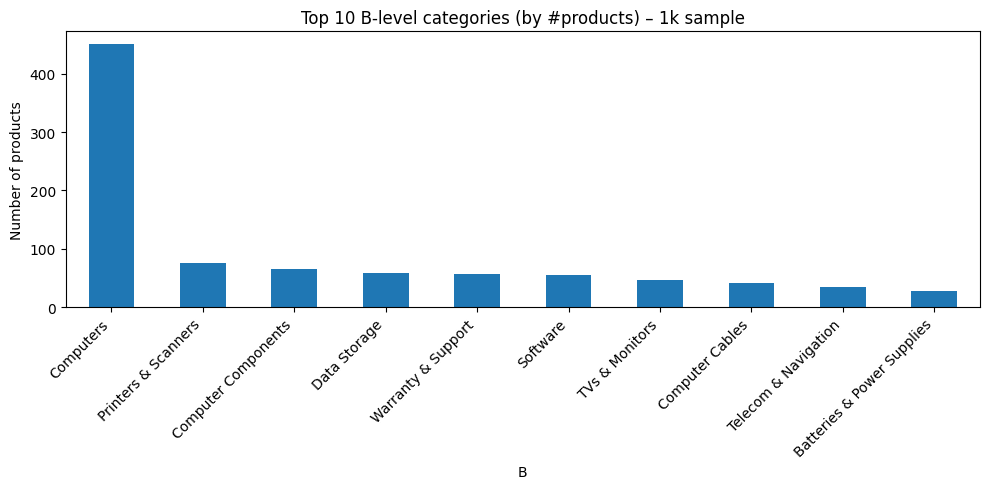

In [22]:
# Visualize imbalance with bar charts
# Bar chart: top 10 B-level categories
import matplotlib.pyplot as plt

# Reuse B_counts from above
top_B = B_counts.head(10)

plt.figure(figsize=(10, 5))
top_B.plot(kind="bar")
plt.title("Top 10 B-level categories (by #products) – 1k sample")
plt.ylabel("Number of products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

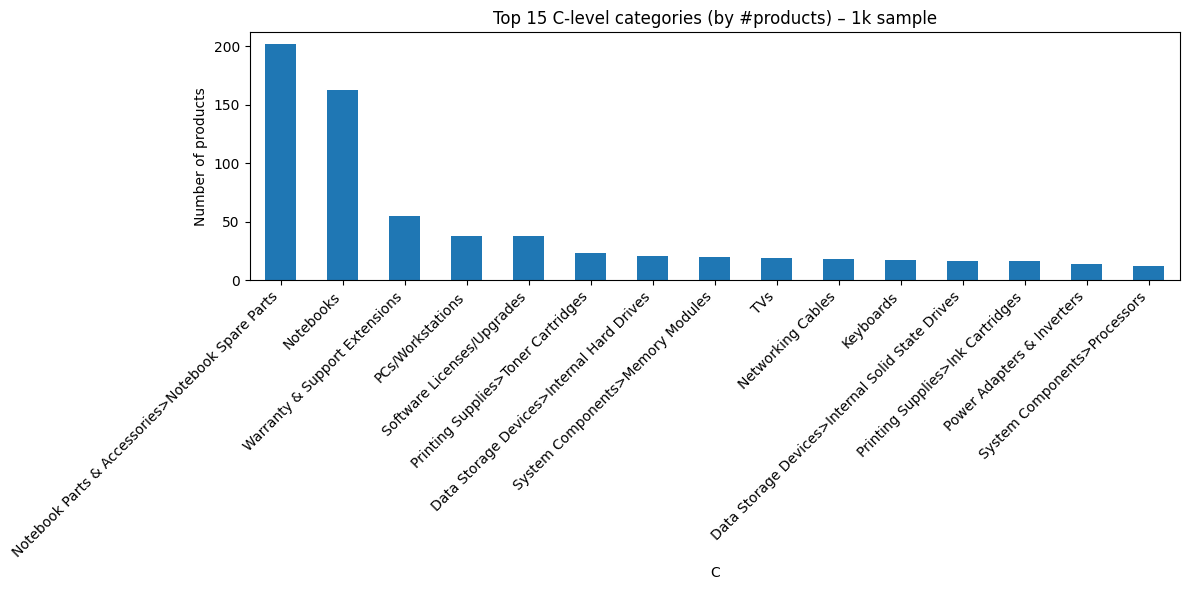

In [23]:
# Bar chart: top 15 C-level categories
top_C = C_counts.head(15)

plt.figure(figsize=(12, 6))
top_C.plot(kind="bar")
plt.title("Top 15 C-level categories (by #products) – 1k sample")
plt.ylabel("Number of products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# Create a “balanced” subset (for later modeling)
# Now we decide a threshold:
# For example:
# Keep only C-level categories with at least 5 products in this 1k sample.
# You can change 5 → 3, 10, etc.

In [25]:
MIN_PROD_PER_C = 5

# Find which C categories are "big enough"
valid_C = C_prod_counts.loc[
    C_prod_counts["num_products_under_C"] >= MIN_PROD_PER_C,
    "C"
].unique()

len_valid_C = len(valid_C)
print(f"Number of C categories with >= {MIN_PROD_PER_C} products:", len_valid_C)

# Filter df_small accordingly
df_balanced = df_small[df_small["C"].isin(valid_C)].copy()
print("Original df_small size:", len(df_small))
print("Balanced df size:", len(df_balanced))


Number of C categories with >= 5 products: 31
Original df_small size: 1000
Balanced df size: 793


In [26]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 793 entries, 1072689 to 1094976
Data columns (total 48 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Brand                                       793 non-null    object 
 1   BrandInfo.BrandLocalName                    793 non-null    object 
 2   BrandInfo.BrandLogo                         792 non-null    object 
 3   BrandInfo.BrandName                         793 non-null    object 
 4   BrandLogo                                   792 non-null    object 
 5   BrandPartCode                               793 non-null    object 
 6   BulletPoints                                738 non-null    object 
 7   Category.CategoryID                         793 non-null    int64  
 8   Category.Name.Language                      793 non-null    object 
 9   Category.Name.Value                         793 non-null    object 
 10  Descripti

In [27]:
df_small[df_small["C"] == "PCs/Workstations"].shape
df_small[df_small["C"] == "PCs/Workstations"]["ProductName"].tolist()


['K31CD-IT049T',
 'C30',
 'UN42-M031M',
 'P310',
 '875-1303ng',
 '400 G6',
 'M910q',
 '3 VR7RD-037US',
 '400 G4 + EliteDisplay E223',
 'ProDesk 600 G3 Desktop Mini PC',
 'G11CD-FR139T',
 'S2660G',
 'h8-1500et',
 'Compaq Presario SG3320IL Desktop PC',
 'TC-710',
 'XC605',
 'DM500T4Z',
 'M32CD-IT051T',
 'A 8RC-290FR',
 'Z640',
 'Compaq 6200 Pro Microtower PC (ENERGY STAR)',
 'Z440',
 'P500',
 '550-131ns',
 '5680',
 'P420 E85+',
 'M83',
 '595-p0059nl',
 'K20CD-KR002D',
 '690-0043ns',
 'Aegis Ti3 VR7RD',
 'S510 + 19.5" LED ThinkVision E2054',
 '800 G4 + LaserJet Pro M15w',
 '800 G4',
 'M73',
 'Y700-34ISH',
 'M770',
 '690-0999nf']

In [ ]:
# Choose important text columns
TEXT_COLS = [
    "Brand",
    "ProductName",
    "Title",
    "Description.LongProductName",
    "Description.LongDesc",
    "SummaryDescription.LongSummaryDescription",
    "SummaryDescription.ShortSummaryDescription",
    "Category.Name.Value",
    "pathlist_names",
]


In [29]:
# Merge them into one metadata_text
def merge_text_fields(row, cols):
    parts = []
    for c in cols:
        val = row.get(c, None)
        if pd.isna(val):
            continue
        if isinstance(val, str):
            val = val.strip()
        if val:
            parts.append(str(val))
    return " ".join(parts)


df_balanced["metadata_text"] = df_balanced.apply(
    lambda r: merge_text_fields(r, TEXT_COLS),
    axis=1
)


In [30]:
#clean the text
import re

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    # remove HTML tags like <br>, <b>, etc.
    s = re.sub(r"<[^>]+>", " ", s)
    # keep only letters, numbers, and basic punctuation
    s = re.sub(r"[^a-z0-9\s\-\.,]", " ", s)
    # collapse multiple spaces
    s = re.sub(r"\s+", " ", s)
    return s.strip()

df_balanced["metadata_text_clean"] = df_balanced["metadata_text"].apply(clean_text)


In [35]:

df_clean = df_balanced[[
    "Brand",
    "BrandPartCode",
    "ProductName",
    "Description.LongProductName",
    "Description.LongDesc",
    "SummaryDescription.LongSummaryDescription",
    "pathlist_names",      # keep original Icecat path
    "A", "B", "C",         # expert A/B/C levels (for analysis + evaluation)
    "metadata_text",
    "metadata_text_clean", # used for embeddings + clustering
]].copy()

df_clean.head(3).T


,1072689,906402,411281
Brand,ASUS,HP,C2G
BrandPartCode,K31CD-IT049T,686915-A41,37745
ProductName,K31CD-IT049T,686915-A41,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...
Description.LongProductName,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",Keyboard in midnight black finish with backlig...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...
Description.LongDesc,<b>Smart Multimedia Performance</b><br>\nVivoP...,,Get the performance you demand at a price that...
SummaryDescription.LongSummaryDescription,ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,HP 686915-A41. Type: Keyboard. Keyboard langua...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...
pathlist_names,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics>Computer Cables>Fibre ...
A,Computers & Electronics,Computers & Electronics,Computers & Electronics
B,Computers,Computers,Computer Cables
C,PCs/Workstations,Notebook Parts & Accessories>Notebook Spare Parts,Fibre Optic Cables


In [32]:
df_balanced.head()

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,...,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names,A,B,C,metadata_text,metadata_text_clean
1072689,ASUS,,https://images.icecat.biz/img/brand/thumb/161_...,ASUS,https://images.icecat.biz/img/brand/thumb/161_...,K31CD-IT049T,[],153,EN,PCs/Workstations,...,None,"[{'VirtualCategoryID': 195, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,Computers,PCs/Workstations,ASUS K31CD-IT049T ASUS K31CD-IT049T PC 6th gen...,asus k31cd-it049t asus k31cd-it049t pc 6th gen...
906402,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,686915-A41,[],2509,EN,Notebook Spare Parts,...,None,None,NaN,2833>150>8355>2509,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,Computers,Notebook Parts & Accessories>Notebook Spare Parts,HP 686915-A41 HP 686915-A41 notebook spare par...,hp 686915-a41 hp 686915-a41 notebook spare par...
411281,C2G,,https://images.icecat.biz/img/brand/thumb/2834...,C2G,https://images.icecat.biz/img/brand/thumb/2834...,37745,[],953,EN,Fibre Optic Cables,...,None,None,NaN,2833>830>953,Computers & Electronics>Computer Cables>Fibre ...,Computers & Electronics,Computer Cables,Fibre Optic Cables,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,c2g 1m st sc plenum-rated 9 125 duplex single-...
1047582,Lenovo,,https://images.icecat.biz/img/brand/thumb/728_...,Lenovo,https://images.icecat.biz/img/brand/thumb/728_...,109559U,[],153,EN,PCs/Workstations,...,None,"[{'VirtualCategoryID': 194, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics,Computers,PCs/Workstations,Lenovo C30 Lenovo ThinkStation C30 Intel® Xeon...,lenovo c30 lenovo thinkstation c30 intel xeon ...
904910,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,659501-BB1,[],2509,EN,Notebook Spare Parts,...,None,None,NaN,2833>150>8355>2509,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics,Computers,Notebook Parts & Accessories>Notebook Spare Parts,HP 659501-BB1 HP 659501-BB1 notebook spare par...,hp 659501-bb1 hp 659501-bb1 notebook spare par...


In [36]:
##84-dims Embeddings using Sentence Bert
from sentence_transformers import SentenceTransformer
import numpy as np

# 1. Choose model
EMB_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMB_MODEL_NAME)

# 2. Get the cleaned text (fallback to "" if NaN)
texts = df_clean["metadata_text_clean"].fillna("").tolist()
print("Number of texts:", len(texts))

# 3. Compute embeddings (384-dim)
embeddings = embedder.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # cosine similarity friendly
)

embeddings.shape


Number of texts: 793


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

(793, 384)

In [37]:
# UMAP dimensionality reduction
# We compress 384 → 25 dimensions to make clustering easier.
from umap import UMAP

# 1. Configure UMAP
umap_model = UMAP(
    n_components=25,
    n_neighbors=30,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

# 2. Fit + transform
umap_vectors = umap_model.fit_transform(embeddings)
umap_vectors.shape


(793, 25)

In [38]:
# Store each UMAP dimension as a column U0, U1, ..., U24
for i in range(umap_vectors.shape[1]):
    df_clean[f"U{i}"] = umap_vectors[:, i]

df_clean.head(3).T


,1072689,906402,411281
Brand,ASUS,HP,C2G
BrandPartCode,K31CD-IT049T,686915-A41,37745
ProductName,K31CD-IT049T,686915-A41,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...
Description.LongProductName,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",Keyboard in midnight black finish with backlig...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...
Description.LongDesc,<b>Smart Multimedia Performance</b><br>\nVivoP...,,Get the performance you demand at a price that...
SummaryDescription.LongSummaryDescription,ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,HP 686915-A41. Type: Keyboard. Keyboard langua...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...
pathlist_names,Computers & Electronics>Computers>PCs/Workstat...,Computers & Electronics>Computers>Notebook Par...,Computers & Electronics>Computer Cables>Fibre ...
A,Computers & Electronics,Computers & Electronics,Computers & Electronics
B,Computers,Computers,Computer Cables
C,PCs/Workstations,Notebook Parts & Accessories>Notebook Spare Parts,Fibre Optic Cables


In [39]:
# HDBSCAN clustering on UMAP vectors
# Now cluster the 25-dim UMAP vectors → this gives C-level clusters.
import hdbscan

# Use only the UMAP columns as features
U_cols = [c for c in df_clean.columns if c.startswith("U")]
X = df_clean[U_cols].values

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,   # tune later
    min_samples=5,         # tune later
    metric="euclidean",
    cluster_selection_epsilon=0.0,
    cluster_selection_method="eom",
)

cluster_labels = clusterer.fit_predict(X)

# Add cluster IDs
df_clean["C_id"] = cluster_labels

# Quick summary
print("Unique C_id labels:", np.unique(cluster_labels))
print("\nCluster sizes (including noise -1):")
print(df_clean["C_id"].value_counts().sort_index())


Unique C_id labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]

Cluster sizes (including noise -1):
C_id
-1      39
 0      25
 1      57
 2      47
 3      57
 4      56
 5      36
 6     102
 7      72
 8      26
 9      29
 10     48
 11     52
 12     84
 13     63
Name: count, dtype: int64


In [ ]:
# # Build cluster → evidence mapping

# from collections import defaultdict

# cluster_texts = defaultdict(list)

# # Build text lists for each cluster
# for cid, text in zip(df_clean["C_id"], df_clean["metadata_text_clean"]):
#     if isinstance(text, str):
#         cluster_texts[cid].append(text)

# # Create evidence blobs
# cluster_evidence = {}

# MAX_ITEMS = 30   # sample 30 items per cluster
# MAX_CHARS = 1500 # reduce size to avoid LLM overflow

# for cid, items in cluster_texts.items():
#     # sample items
#     sample = items[:MAX_ITEMS]  

#     blob = "\n".join(sample)

#     # trim if too long
#     if len(blob) > MAX_CHARS:
#         blob = blob[:MAX_CHARS]

#     cluster_evidence[cid] = blob

# # inspect one evidence blob
# cid_example = list(cluster_evidence.keys())[1]
# print(f"Cluster {cid_example} evidence:\n")
# print(cluster_evidence[cid_example])
# # gives you 1 blob per cluster, ready for LLaMA prompting.


Cluster 7 evidence:

hp 686915-a41 hp 686915-a41 notebook spare part keyboard keyboard in midnight black finish with backlight for use on all computer models in belgium includes keyboard cable and keyboard backlight cable hp 686915-a41. type keyboard. keyboard language belgian, keyboard backlit. brand compatibility hp, compatibility pavilion m6 hp 686915-a41, keyboard, belgian, keyboard backlit, hp, pavilion m6 notebook spare parts computers electronics computers notebook parts accessories notebook spare parts
hp 659501-bb1 hp 659501-bb1 notebook spare part keyboard keyboard in ash black for use in israel includes keyboard cable hp 659501-bb1. type keyboard. keyboard language hebrew. brand compatibility hp, compatibility pavilion dm1 hp 659501-bb1, keyboard, hebrew, hp, pavilion dm1 notebook spare parts computers electronics computers notebook parts accessories notebook spare parts
lenovo 00ht024 lenovo 00ht024 housing base keyboard notebook housing base keyboard for thinkpad x1 carbon

In [ ]:
import random

def make_evidence(subdf, max_chars=1000, max_items=30):
    """
    Build an evidence blob for ONE cluster.
    - Takes all rows in that cluster (subdf)
    - Uses up to `max_items` product descriptions
    - Joins them and truncates to `max_chars`
    """
    texts = subdf["metadata_text_clean"].dropna().tolist()
    if len(texts) == 0:
        return ""

    # sample up to max_items descriptions
    if len(texts) > max_items:
        sample_texts = random.sample(texts, max_items)
    else:
        sample_texts = texts

    blob = " ".join(sample_texts)
    return blob[:max_chars]
#This is per C_id cluster: it pulls that cluster’s metadata_text_clean, samples ≤30 products, joins, trims to 1000 chars.

In [46]:
import subprocess

def run_llm(prompt, model="llama3.2"):
    """
    Run a prompt on Ollama and return raw text output.
    """
    cmd = ["ollama", "run", model]

    result = subprocess.run(
        cmd,
        input=prompt,
        text=True,
        capture_output=True
    )

    if result.stderr.strip():
        print("⚠ Ollama stderr:\n", result.stderr)

    return result.stdout


In [47]:
import hashlib

label_cache = {}

def cached_llm_label(prompt, max_words=4, model="llama3.2"):
    """
    Send prompt to Ollama only once per unique prompt.
    Result is trimmed to at most `max_words` words.
    """
    key = hashlib.sha256(prompt.encode("utf-8")).hexdigest()

    if key in label_cache:
        return label_cache[key]

    raw = run_llm(prompt, model=model)   # your existing Ollama call
    label = " ".join(raw.strip().split()[:max_words])

    label_cache[key] = label
    return label


In [48]:
C_name_map = {}

unique_cids = sorted(df_clean["C_id"].unique())
print("Unique C_id:", unique_cids)

for cid in unique_cids:
    if cid == -1:   # skip noise cluster
        continue

    subdf = df_clean[df_clean["C_id"] == cid]
    blob = make_evidence(subdf, max_chars=1000, max_items=30)

    if not blob:
        print(f"C_id {cid}: empty blob, skipping")
        continue

    prompt = f"""
You are an expert in product taxonomy.

Based on the following product descriptions, assign a concise C-level
category name (maximum 4 words). ONLY return the category name.

### PRODUCT CLUSTER (examples) ###
{blob}
"""

    label = cached_llm_label(prompt, max_words=4)
    C_name_map[cid] = label

    print(f"C_id {cid} → {label}")


Unique C_id: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


Exception in thread Thread-10 (_readerthread):
Traceback (most recent call last):
  File "C:\Program Files\Python311\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "C:\Program Files\Python311\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Program Files\Python311\Lib\subprocess.py", line 1597, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Program Files\Python311\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 332: character maps to <undefined>


AttributeError: 'NoneType' object has no attribute 'strip'

In [ ]:

#Attach the C-name to all products
df_clean["C_name"] = df_clean["C_id"].map(C_name_map)
df_clean[["ProductName", "C_id", "C_name"]].head(20)
